In [1]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_RfxCas13a_validation_mlp.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_RfxCas13a_validation_mlp.csv", index=False)


                                       Feature     Q1     Q3  \
0                                 crRNA spacer  0.985  0.989   
1  bh_maximal consecutive paired bases (crRNA)  0.980  0.994   
2                       bh_5' overhang (crRNA)  0.706  0.858   
3                           bh_5' stem (crRNA)  0.817  0.864   
4                           bh_3' stem (crRNA)  0.505  0.732   
5  bh_maximal consecutive paired bases (ssRNA)  0.895  0.973   
6                       bh_3' overhang (ssRNA)  0.176  0.801   
7                          PFS-proximal region  0.416  0.986   

   Median Spearman Correlation  
0                        0.987  
1                        0.993  
2                        0.852  
3                        0.861  
4                        0.732  
5                        0.966  
6                        0.715  
7                        0.924  


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_52573/1753623565.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


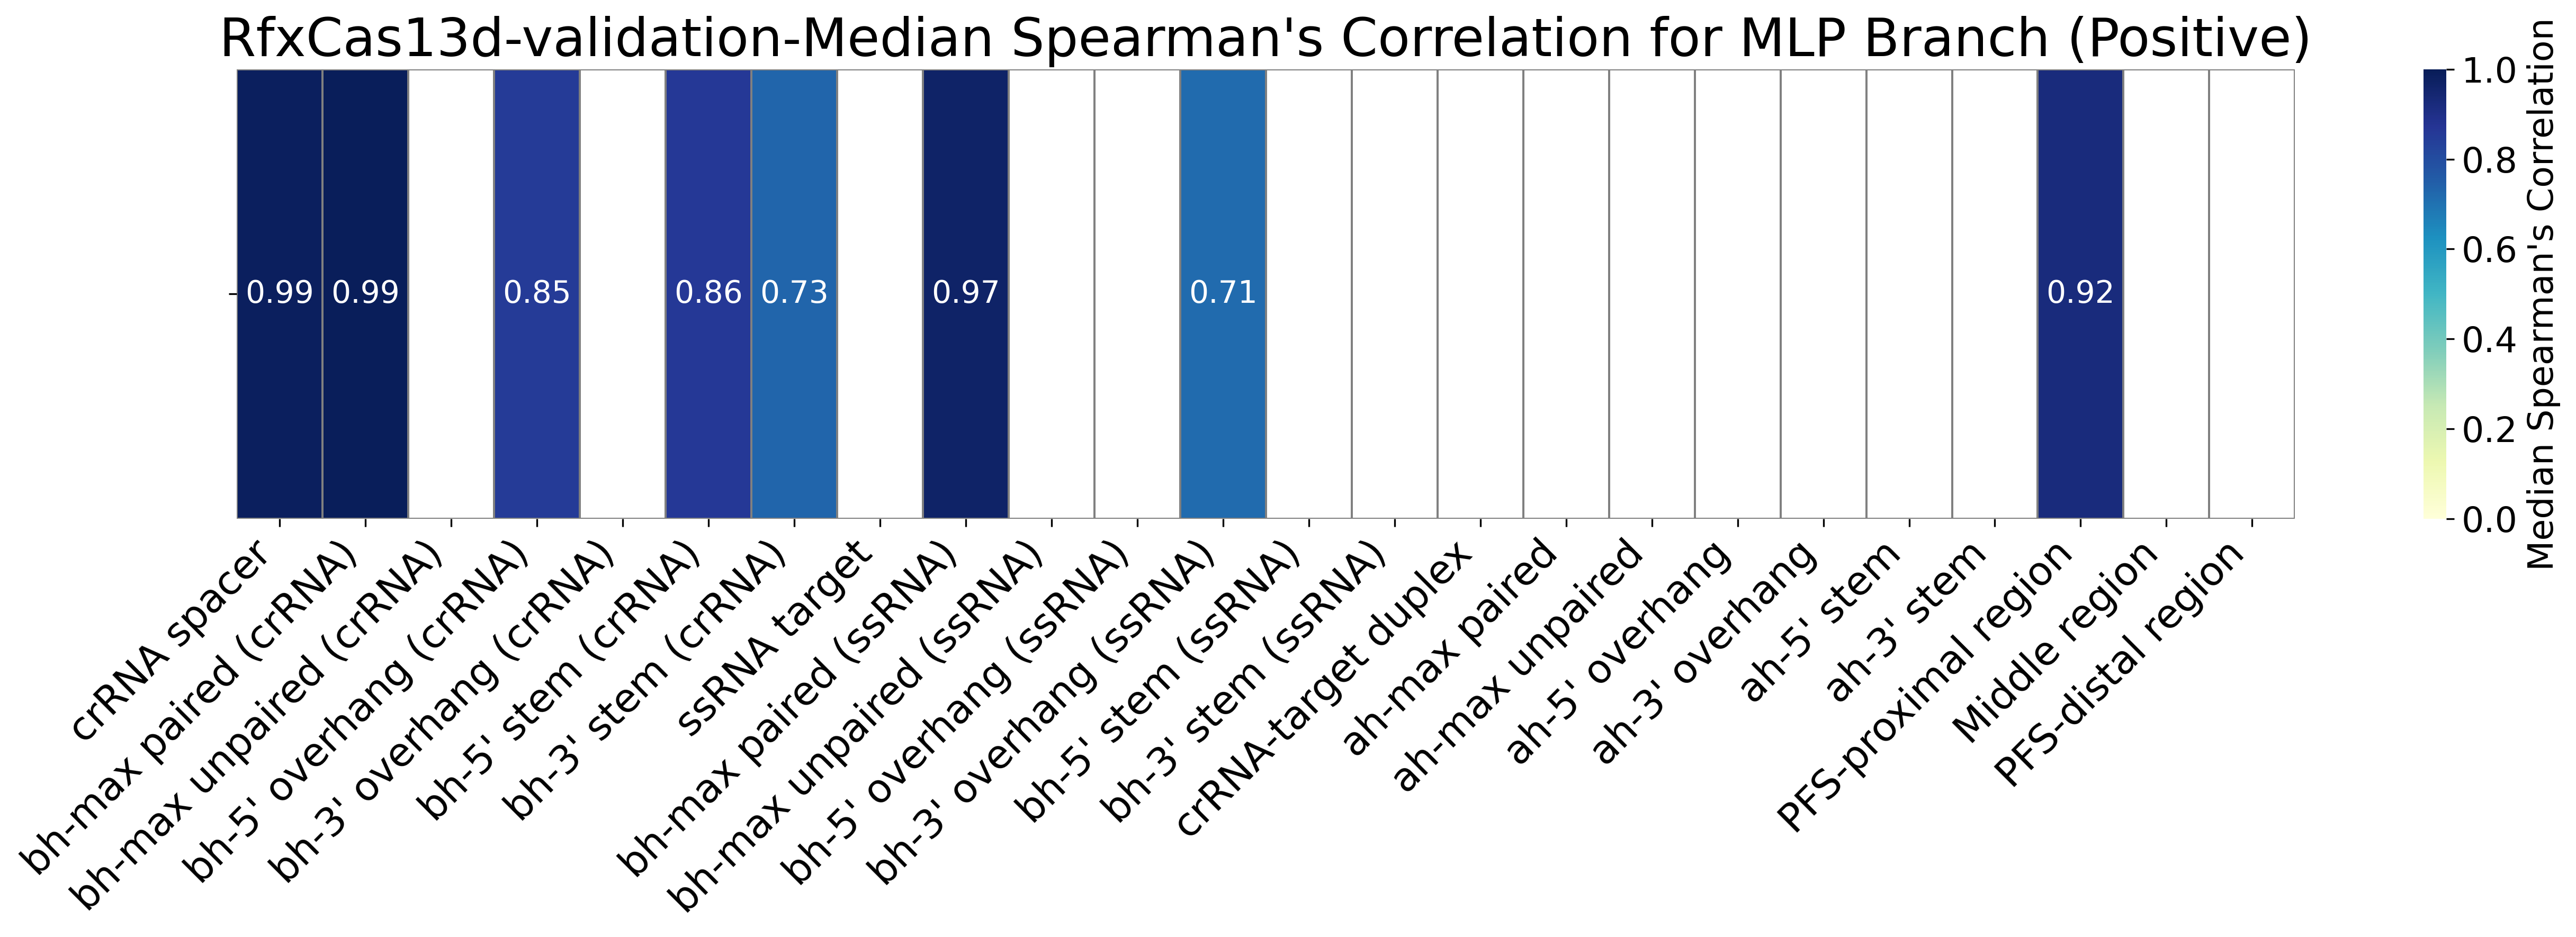

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- desired full feature order (17 columns) ----
feature_order = [
    "crRNA spacer",
    "bh_maximal consecutive paired bases (crRNA)",
    "bh_maximal consecutive unpaired bases (crRNA)",
    "bh_5' overhang (crRNA)",
    "bh_3' overhang (crRNA)",
    "bh_5' stem (crRNA)",
    "bh_3' stem (crRNA)",
    "ssRNA target",
    "bh_maximal consecutive paired bases (ssRNA)",
    "bh_maximal consecutive unpaired bases (ssRNA)",
    "bh_5' overhang (ssRNA)",
    "bh_3' overhang (ssRNA)",
    "bh_5' stem (ssRNA)",
    "bh_3' stem (ssRNA)",
    "crRNA-target duplex",
    "ah_maximal consecutive paired bases (crRNA in duplex)",
    "ah_maximal consecutive unpaired bases (crRNA in duplex)",
    "ah_5' overhang (crRNA in duplex)",
    "ah_3' overhang (crRNA in duplex)",
    "ah_5' stem (crRNA in duplex)",
    "ah_3' stem (crRNA in duplex)",
    "PFS-proximal region",
    "central region",
    "PFS-distal region"
]

csv_path = "features_with_positive_IQR_RfxCas13a_validation_mlp.csv"
value_col = "Median Spearman Correlation"   # change if your column name differs
feature_col = "Feature"                     # change if your feature-name column differs

# ---- load ----
df = pd.read_csv(csv_path)

# Optional: if duplicates exist, average them
df = df.groupby(feature_col, as_index=False)[value_col].mean()

# ---- build a 1x17 table: row label "MLP", columns are the 17 features ----
# Map available features into a Series indexed by Feature name
s = df.set_index(feature_col)[value_col]

# Reindex to force all 17 features to exist; missing -> NaN
s = s.reindex(feature_order)

heatmap_data = pd.DataFrame([s.values], index=[""], columns=feature_order)

# ---- plot (NaN will be blank if masked) ----
mask = heatmap_data.isna()

fig, ax = plt.subplots(figsize=(18, 6), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Median Spearman's Correlation"},
    annot_kws={"fontsize": 14},
    ax=ax
)

ax.set_ylabel("")  # 1-row heatmap; optional
ax.set_xlabel("")
ax.set_title("RfxCas13d-validation-Median Spearman's Correlation for MLP Branch (Positive)", fontsize=24)

# Rotate x tick labels + align to the right (NOTE: use set_xticklabels for alignment)
short_labels = [
    "crRNA spacer",
    "bh-max paired (crRNA)",
    "bh-max unpaired (crRNA)",
    "bh-5' overhang (crRNA)",
    "bh-3' overhang (crRNA)",
    "bh-5' stem (crRNA)",
    "bh-3' stem (crRNA)",
    "ssRNA target",
    "bh-max paired (ssRNA)",
    "bh-max unpaired (ssRNA)",
    "bh-5' overhang (ssRNA)",
    "bh-3' overhang (ssRNA)",
    "bh-5' stem (ssRNA)",
    "bh-3' stem (ssRNA)",
    "crRNA-target duplex",
    "ah-max paired",
    "ah-max unpaired",
    "ah-5' overhang",
    "ah-3' overhang",
    "ah-5' stem",
    "ah-3' stem",
    "PFS-proximal region",
    "Middle region",
    "PFS-distal region"
]

ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_RfxCas13a_validation_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_RfxCas13a_validation_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0   Pos37_A  0.555  0.776                        0.684
1   Pos37_C  0.052  0.482                        0.345
2   Pos38_A  0.197  0.678                        0.327
3   Pos38_C  0.436  0.576                        0.484
4   Pos39_A  0.246  0.578                        0.447
5   Pos43_A  0.123  0.482                        0.320
6   Pos44_A  0.168  0.562                        0.449
7   Pos44_U  0.038  0.377                        0.326
8   Pos45_A  0.482  0.719                        0.602
9   Pos45_U  0.055  0.490                        0.324
10  Pos46_A  0.182  0.514                        0.447
11  Pos46_U  0.265  0.690                        0.490
12  Pos47_U  0.348  0.593                        0.487
13  Pos48_U  0.267  0.549                        0.458
14  Pos49_U  0.381  0.564                        0.460
15  Pos50_U  0.136  0.337                        0.284
16  Pos51_G  0.231  0.565                        0.513
17  Pos52_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_52573/98762204.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


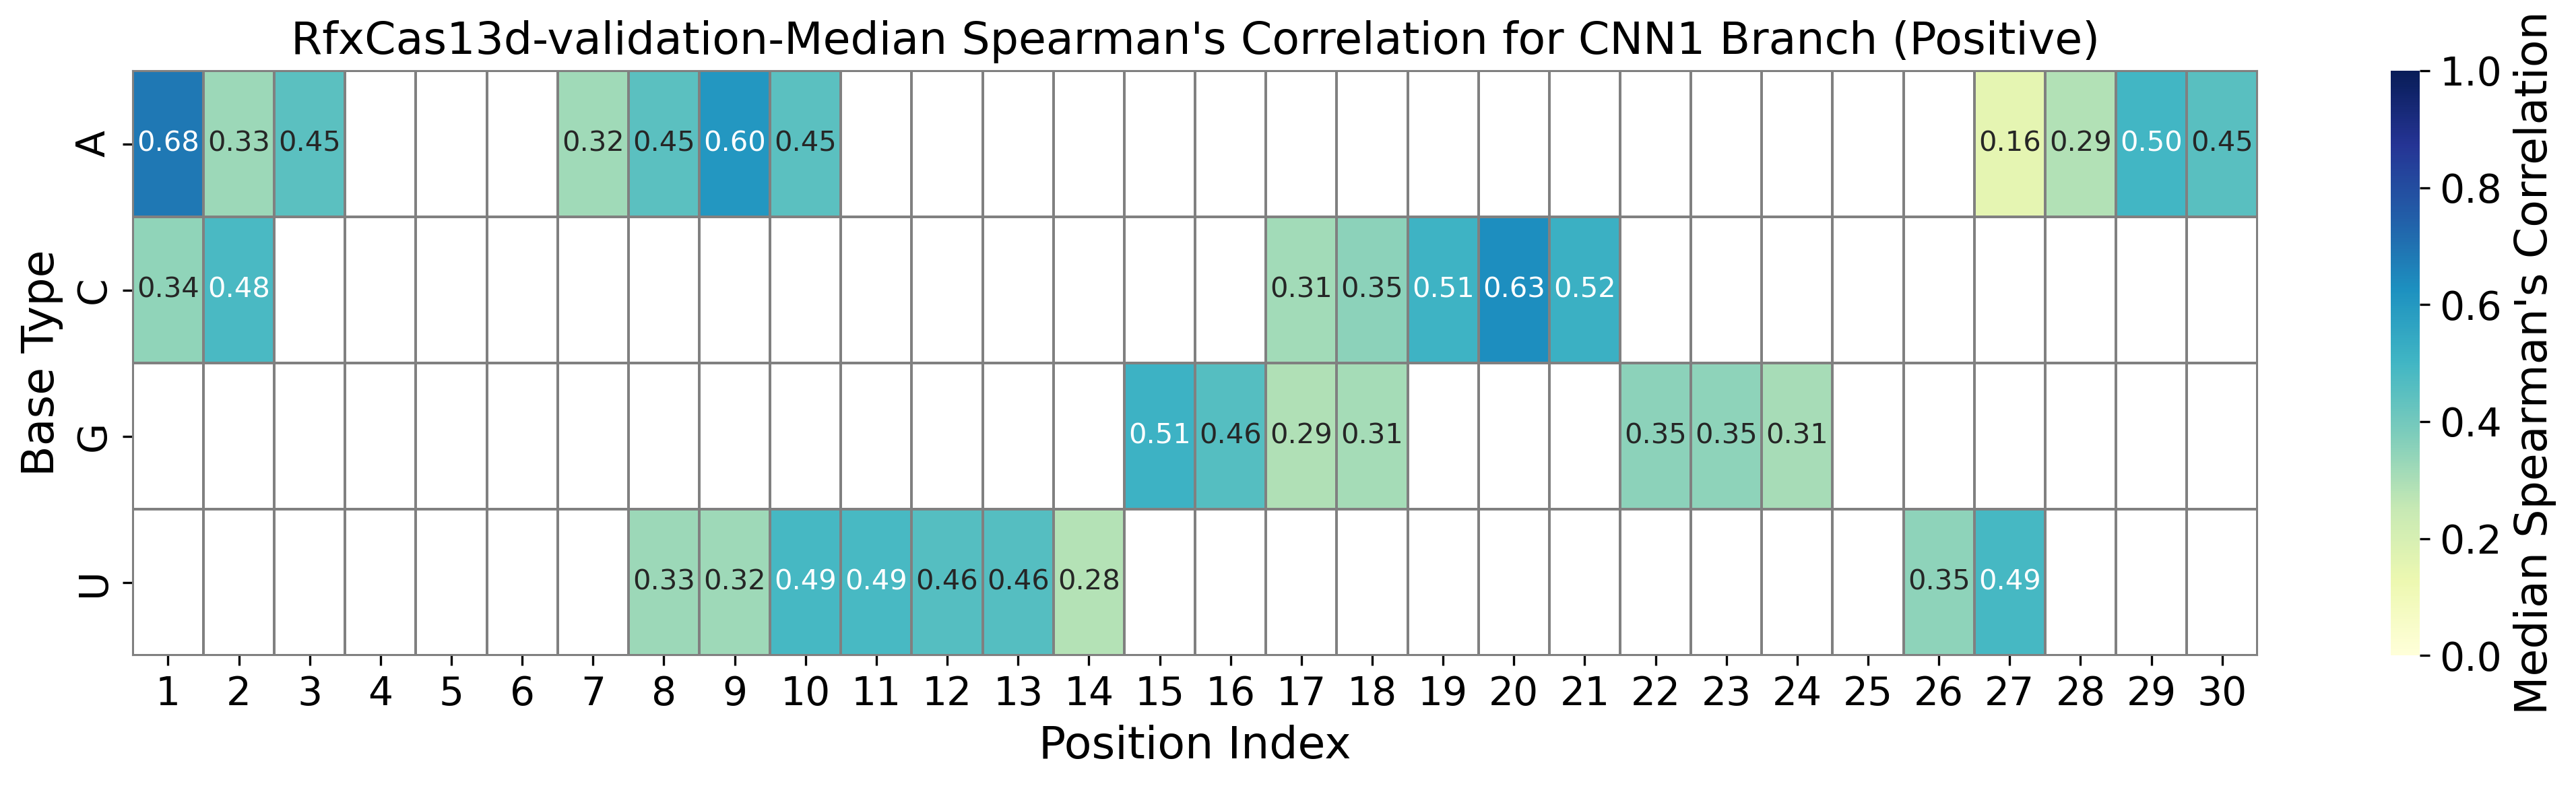

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("features_with_positive_IQR_RfxCas13a_validation_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all four base types are present, even if some rows are all NaN
base_order = ['A', 'C', 'G', 'U']
heatmap_data = heatmap_data.reindex(base_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

# Force x-axis labels to start from 1
n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)

# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("RfxCas13d-validation-Median Spearman's Correlation for CNN1 Branch (Positive)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_RfxCas13a_validation_cnn2.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_RfxCas13a_validation_cnn2.csv", index=False)


                 Feature     Q1     Q3  Median Spearman Correlation
0    Pos1_Paired-Opening  0.385  0.385                        0.385
1    Pos2_Paired-Opening  0.370  0.370                        0.370
2    Pos3_Paired-Opening  0.377  0.377                        0.377
3    Pos5_Paired-Opening  0.415  0.415                        0.415
4    Pos6_Paired-Opening  0.113  0.377                        0.280
5    Pos7_Paired-Opening  0.160  0.305                        0.266
6    Pos8_Paired-Opening  0.168  0.242                        0.242
7    Pos9_Paired-Opening  0.158  0.204                        0.203
8   Pos10_Paired-Opening  0.174  0.196                        0.196
9   Pos11_Paired-Opening  0.206  0.211                        0.211
10  Pos12_Paired-Opening  0.099  0.171                        0.154
11        Pos13_Unpaired  0.099  0.181                        0.181
12  Pos14_Paired-Opening  0.136  0.221                        0.145
13  Pos15_Paired-Opening  0.196  0.196          

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_52573/2262353565.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


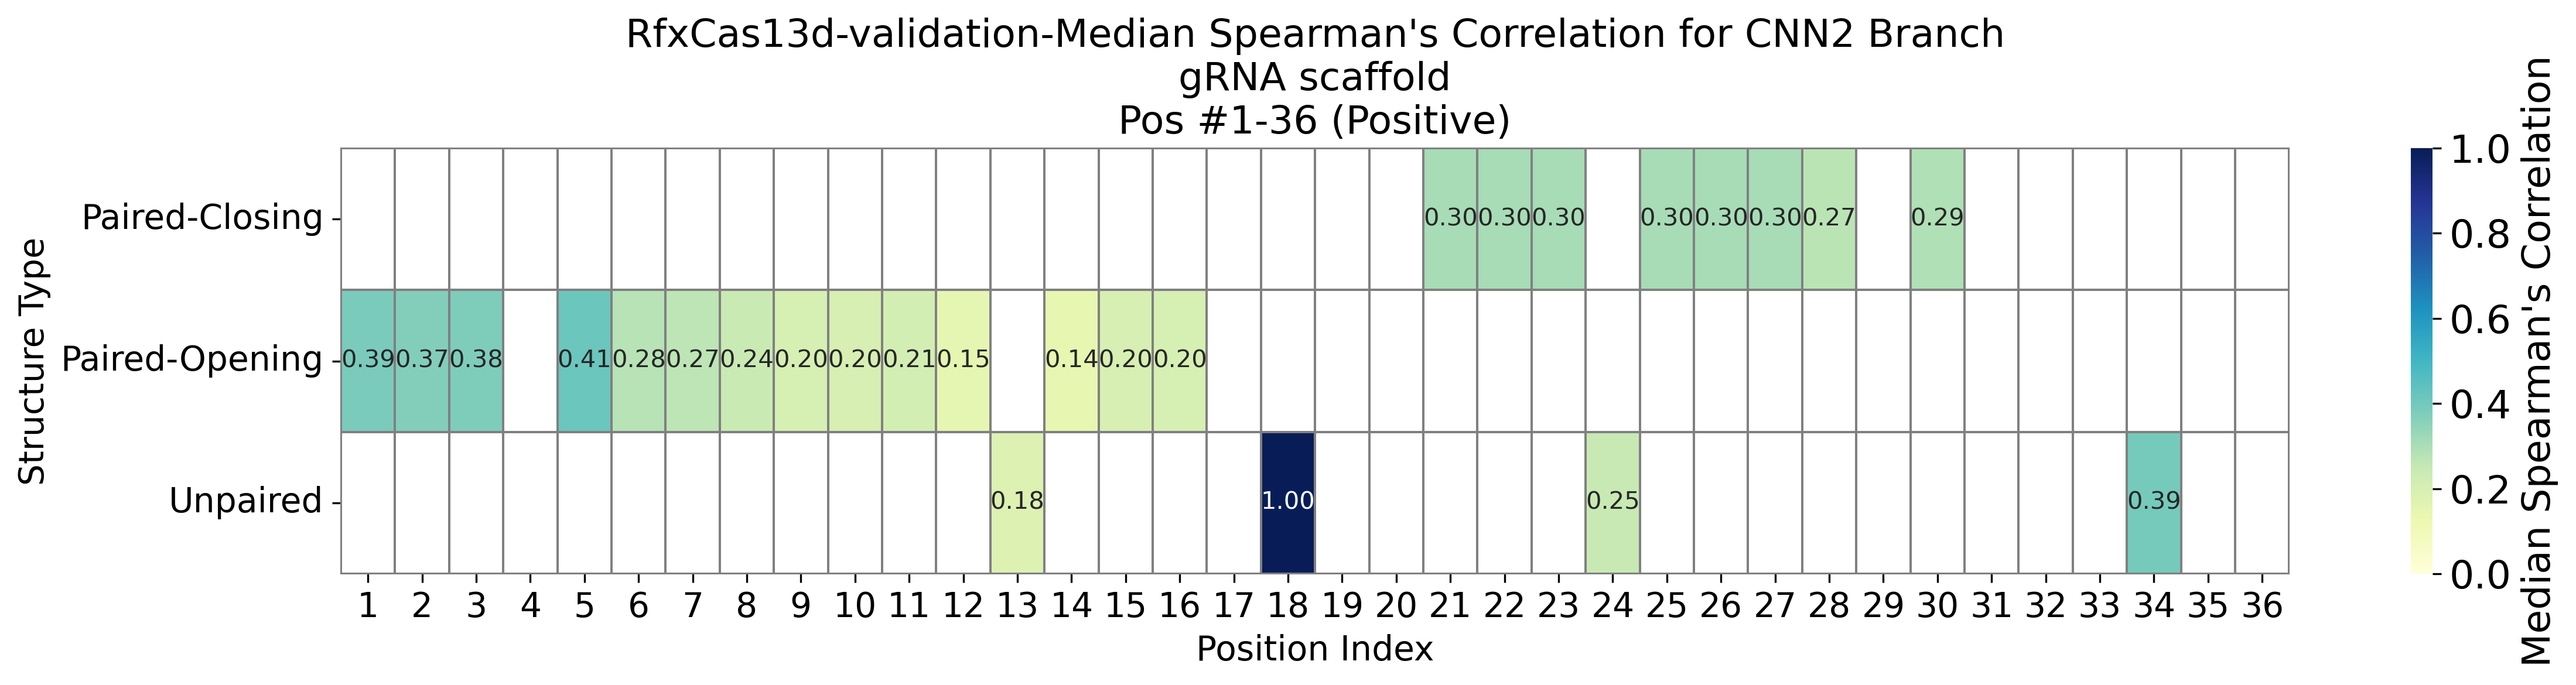

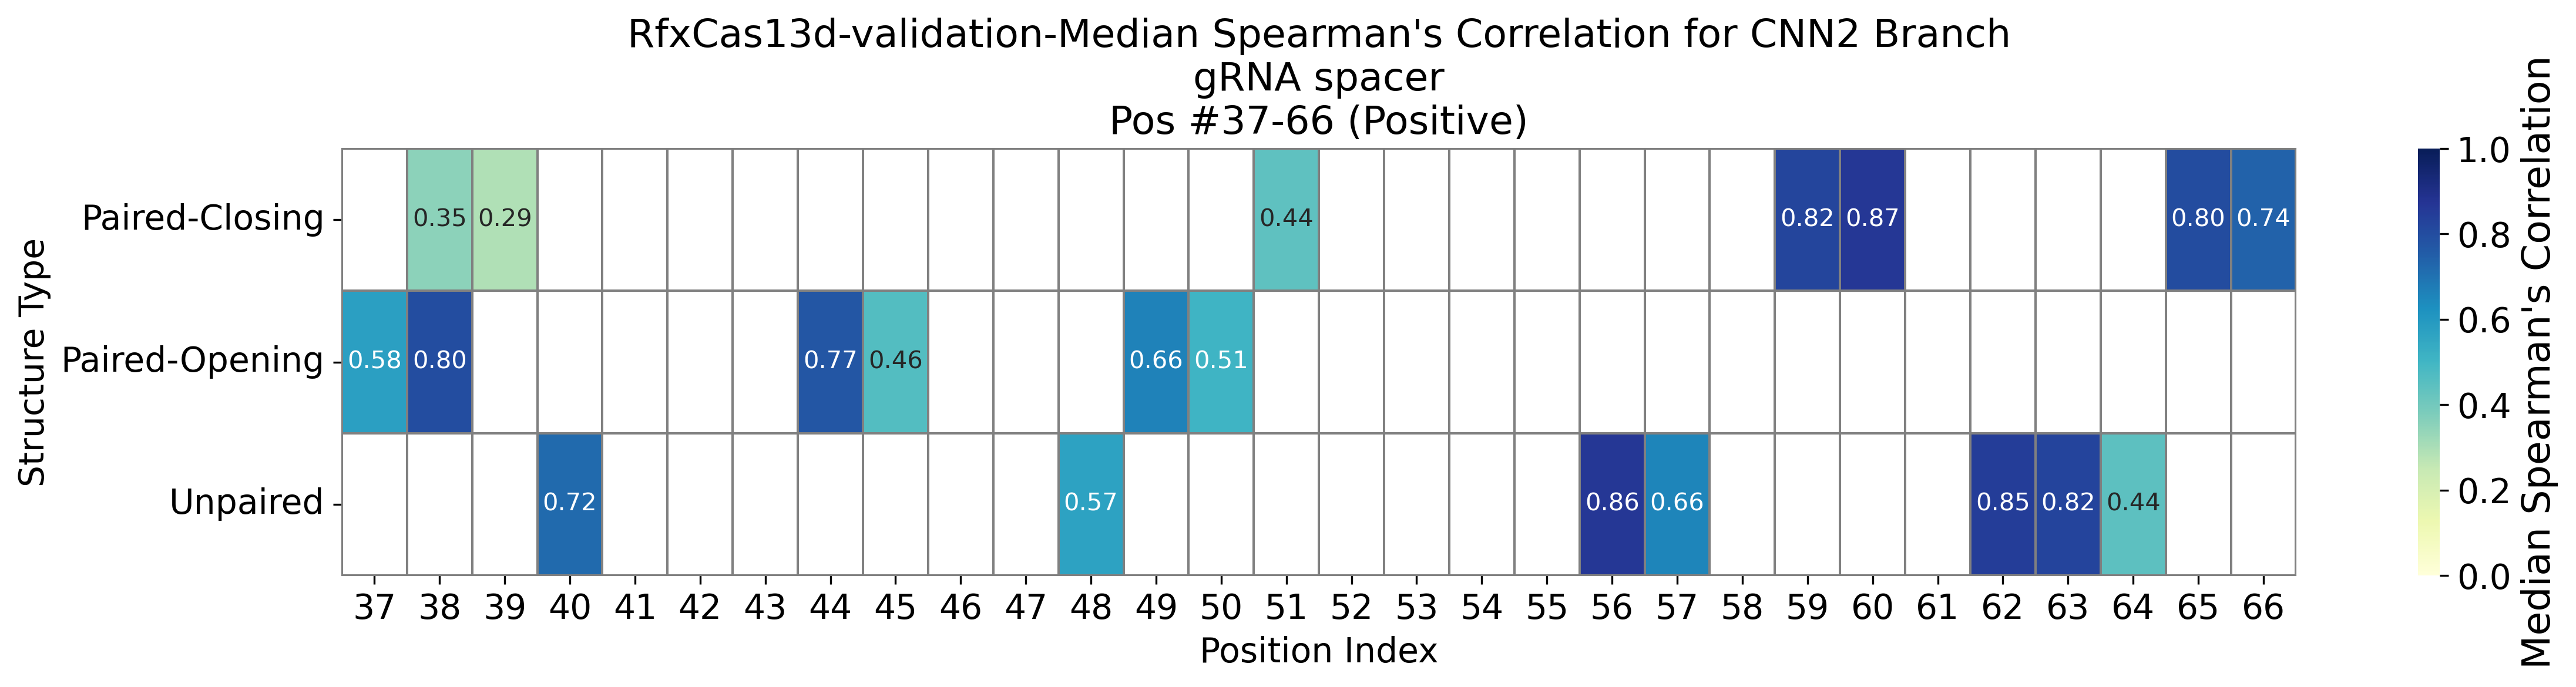

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load processed feature list ===
iqr_df = pd.read_csv("features_with_positive_IQR_RfxCas13a_validation_cnn2.csv")

# === Extract Pos and Base Type (here Base = sub-feature like Paired, Opening, etc.) ===
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(.+)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# === Handle duplicate (Base, Pos) entries by averaging ===
iqr_df_grouped = iqr_df.groupby(['Base', 'Pos'])["Median Spearman Correlation"].mean().reset_index()

# === Pivot to heatmap format ===
heatmap_data = iqr_df_grouped.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Optional: Set fixed row order
row_order = sorted(heatmap_data.index.unique())
heatmap_data = heatmap_data.reindex(row_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(1, 67)  # 1 to 66 inclusive
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

# Create mask for missing values
mask = heatmap_data.isna()

# === Create two heatmap panels ===

# Heatmap for positions 1–36
fig1, ax1 = plt.subplots(figsize=(16, 4), dpi=300)
hm1 = sns.heatmap(
    heatmap_data.loc[:, 1:36],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 1:36].isna(),
    ax=ax1
)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax1.set_xlabel("Position Index", fontsize=14)
ax1.set_ylabel("Structure Type", fontsize=14)
ax1.set_title(
    "RfxCas13d-validation-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA scaffold\n'
    "Pos #1-36 (Positive)",
    fontsize=16
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=16)
cbar1.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

# Heatmap for positions 37-66
fig2, ax2 = plt.subplots(figsize=(16, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 37:66],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 37:66].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=14)
ax2.set_ylabel("Structure Type", fontsize=14)
ax2.set_title(
    "RfxCas13d-validation-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA spacer\n'
    "Pos #37-66 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

